# # Facial Verification with Siamese Networks

## Dependencies setup

Readme.md shows how to setup the envrionment for running this notebook with the correct deps

In [1]:
import os, sys, tensorflow as tf

USE_GPU = os.environ.get("USE_GPU", "0") == "1"
gpus = tf.config.list_physical_devices("GPU")

try:
    if USE_GPU and gpus:
        if sys.platform == "darwin":
            tf.config.optimizer.set_experimental_options({"disable_meta_optimizer": True}) #dodge the known slicon Grappler crash
        print(f"GPU enabled ({len(gpus)} device[s])")
    elif USE_GPU and not gpus:
        hint = "pip install tensorflow-metal==1.2.0" if sys.platform == "darwin" else "install the CUDA build of tensorflow"
        print(f"USE_GPU=1 but no GPU visible -> run `{hint}`, then restart the kernel. Using CPU for now.")
    else:
        tf.config.set_visible_devices([], "GPU") # CPU only
        print("CPU mode (USE_GPU=0)")
except RuntimeError as e:                          # set_visible_devices after TF init (cell re-run)
    print("device config already applied, restart kernel to change. (", e, ")")

print("TensorFlow", tf.__version__, "| visible GPUs:", tf.config.get_visible_devices("GPU"))

GPU enabled (1 device[s])
TensorFlow 2.16.2 | visible GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Conv2D, Dense, MaxPooling2D, Input, Flatten
import tensorflow as tf

## Data Aquisition

In [3]:
POS_PATH = os.path.join('../data', 'positive')
NEG_PATH = os.path.join('../data', 'negative')
ANC_PATH = os.path.join('../data', 'anchor')

os.makedirs(POS_PATH, exist_ok=True)
os.makedirs(NEG_PATH, exist_ok=True)
os.makedirs(ANC_PATH, exist_ok=True)

In [4]:
from pathlib import Path

# Skip extract/copy if negatives already populated
existing = len(list(Path(NEG_PATH).glob("*.jpg")))
if existing > 1000:
    print(f"Negatives already in place ({existing} imgs) - skipping download.")
else:
    import kagglehub, shutil, os, tarfile

    path = kagglehub.dataset_download("atulanandjha/lfwpeople") #https://www.kaggle.com/datasets/atulanandjha/lfwpeople

    # 1. Extract the tgz
    with tarfile.open(f"{path}/lfw-funneled.tgz") as tar:
        tar.extractall(path)
    # 2. Find all jpgs in all subfolders and copy them flatly (shallow)
    for image in Path(path).rglob("*.jpg"):
        shutil.copy2(image, f"{NEG_PATH}/{image.name}")

    print("Data downloaded!")

Negatives already in place (13233 imgs) - skipping download.


## Capture own face data with webcam
- performance improved (better than tutrial code) by using just one `cv2.waitKey(1)` check per loop, instead of one check for each key (a, p, q, ESC). This makes the webcam feed more responsive and less laggy.

In [7]:
import uuid

window_name = 'frame'
cap = cv2.VideoCapture(0)
frame = None

CROP = 400

try:
    if not cap.isOpened():
        raise RuntimeError('Could not open webcam')

    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)

    while True:
        ret, frame = cap.read()
        if not ret or frame is None:
            print('Webcam read failed, stopping capture loop.')
            break

        # center crop
        h, w = frame.shape[:2]
        y0 = max((h - CROP) // 2, 0)
        x0 = max((w - CROP) // 2, 0)
        frame = frame[y0:y0+CROP, x0:x0+CROP, :]

        cv2.imshow(window_name, frame)

        key = cv2.waitKey(1) & 0xFF #just one check makes it react faster without any lag
        # Collect anchors
        if key == ord('a'):
            imgname = os.path.join(ANC_PATH, '{}.jpg'.format(uuid.uuid1()))
            cv2.imwrite(imgname, frame)

        # Collect positives
        elif key == ord('p'):
            imgname = os.path.join(POS_PATH, '{}.jpg'.format(uuid.uuid1()))
            cv2.imwrite(imgname, frame)

        # Exit on q or ESC
        elif key == ord('q') or key == 27:
            break

        # Exit on close of OpenCV window
        if cv2.getWindowProperty(window_name, cv2.WND_PROP_VISIBLE) < 1:
            break
except KeyboardInterrupt:
    print('Capture interrupted by user.')
finally:
    cap.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)

## Data Preprocessing

In [8]:
anchor = tf.data.Dataset.list_files(ANC_PATH + '/*.jpg').take(300)
positive = tf.data.Dataset.list_files(POS_PATH + '/*.jpg').take(300)
negative = tf.data.Dataset.list_files(NEG_PATH + '/*.jpg').take(300)

2026-06-20 17:30:59.345556: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2026-06-20 17:30:59.345652: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2026-06-20 17:30:59.345659: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.66 GB
2026-06-20 17:30:59.346476: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-06-20 17:30:59.346496: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [10]:
def preprocess(file_path):
    """resize and normalize image"""
    byte_img = tf.io.read_file(file_path)
    img = tf.io.decode_jpeg(byte_img)

    img = tf.image.resize(img, (100,100))
    img = img / 255.0

    return img

# create labeled dataset

In [11]:
positives = tf.data.Dataset.zip((anchor, positive, tf.data.Dataset.from_tensor_slices(tf.ones(len(anchor)))))
negatives = tf.data.Dataset.zip((anchor, negative, tf.data.Dataset.from_tensor_slices(tf.zeros(len(anchor)))))
data = positives.concatenate(negatives)

In [12]:
samples = data.as_numpy_iterator().next()
print(samples)

(b'../data/anchor/d3f6a376-5da2-11f1-ba05-3e4fef0134de.jpg', b'../data/positive/a82297d6-6cb7-11f1-a15b-3e4fef0134de.jpg', 1.0)


## create train and test partitions

In [13]:
def preprocess_twin(input_img, validation_img, label):
    return (preprocess(input_img), preprocess(validation_img), label)

In [14]:
data = data.map(preprocess_twin)
data = data.cache()
data = data.shuffle(buffer_size=1024)

In [15]:
train_data = data.take(round(len(data)*.7))
train_data = train_data.batch(16)
train_data = train_data.prefetch(8)

In [16]:
test_data = data.skip(round(len(data)*.7))
test_data = test_data.take(round(len(data)*.3))
test_data = test_data.batch(16)
test_data = test_data.prefetch(8)

## Model Creation

In [17]:
def make_embedding():
    inp = Input(shape=(100,100,3), name='input_image')

    c1 = Conv2D(64, (10,10), activation='relu')(inp)
    m1 = MaxPooling2D(64, (2,2), padding='same')(c1)

    c2 = Conv2D(128, (7,7), activation='relu')(m1)
    m2 = MaxPooling2D(64, (2,2), padding='same')(c2)

    c3 = Conv2D(128, (4,4), activation='relu')(m2)
    m3 = MaxPooling2D(64, (2,2), padding='same')(c3)

    c4 = Conv2D(256, (4,4), activation='relu')(m3)
    f1 = Flatten()(c4)
    d1 = Dense(4096, activation='sigmoid')(f1)

    return Model(inputs=inp, outputs=d1, name='embedding')

In [18]:
embedding = make_embedding()
embedding.summary(print_fn=print)

Model: "embedding"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 91, 91, 64)     │        19,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 40, 128)    │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼──────────────────────

# Siamese L1 Distance class

In [19]:
class L1Dist(Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, input_embedding, validation_embedding):
        return tf.math.abs(input_embedding - validation_embedding)

# Siamese model

In [20]:
def make_siamese_model():

    input_image = Input(name='input_img', shape=(100,100,3))

    validation_image = Input(name='validation_img', shape=(100,100,3))

    siamese_layer = L1Dist()
    siamese_layer._name = 'distance'
    distances = siamese_layer(embedding(input_image), embedding(validation_image))

    #break down into one sigmoid value
    classifier = Dense(1, activation='sigmoid')(distances)

    return Model(inputs=[input_image, validation_image], outputs=classifier, name='SiameseNetwork')

In [21]:
siamese_model = make_siamese_model()
siamese_model.summary(print_fn=print)

Model: "SiameseNetwork"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_img           │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ validation_img      │ (None, 100, 100,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 4096)      │ 38,960,448 │ input_img[0][0],  │
│ (Functional)        │                   │            │ validation_img[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l1_dist (L1Dist)    │ (None, 4096)      │         

## Training
- removed checkpoint callback to speed up training, since the model is small and trains quickly.

In [22]:
loss = tf.losses.BinaryCrossentropy()
opt = tf.optimizers.Adam(0.0001)

In [23]:
@tf.function
def train_step(batch):
    with tf.GradientTape() as tape:
        x = batch[:2]
        y = batch[2]
        y_pred = siamese_model(x, training=True)
        loss_value = loss(y, y_pred)

    grad = tape.gradient(loss_value, siamese_model.trainable_variables)
    opt.apply_gradients(zip(grad, siamese_model.trainable_variables))

    return loss_value

In [24]:
def train(data, EPOCHS):
    for epoch in range(1, EPOCHS+1):
        print(f'Epoch {epoch}/{EPOCHS}')
        progbar = tf.keras.utils.Progbar(len(data))
        for idx, batch in enumerate(data.as_numpy_iterator()):
            loss_value = train_step(batch)
            progbar.update(idx+1, [('loss', loss_value.numpy())])

In [25]:
EPOCHS = 50
train(train_data, EPOCHS)
print('Finished training!')

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 12s 962ms/step - loss: 0.3252
Epoch 2/50


2026-06-20 17:32:47.630115: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 870ms/step - loss: 0.3571
Epoch 3/50


2026-06-20 17:32:57.248087: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 872ms/step - loss: 0.3793
Epoch 4/50


...

2026-06-20 17:40:15.307160: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 860ms/step - loss: 1.5327e-07
Epoch 50/50


2026-06-20 17:40:24.814227: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 858ms/step - loss: 2.3619e-05


2026-06-20 17:40:34.307814: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Evaluation

In [26]:
test_input, test_val, y_true = test_data.as_numpy_iterator().next()

In [28]:
y_hat = siamese_model.predict([test_input, test_val])
[1 if prediction > 0.5 else 0 for prediction in y_hat ]
y_true

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


array([0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.],
      dtype=float32)

In [29]:
from tensorflow.keras.metrics import Precision, Recall

m = Recall()
m.update_state(y_true, y_hat)
m.result().numpy()

m = Precision()
m.update_state(y_true, y_hat)
m.result().numpy()

1.0

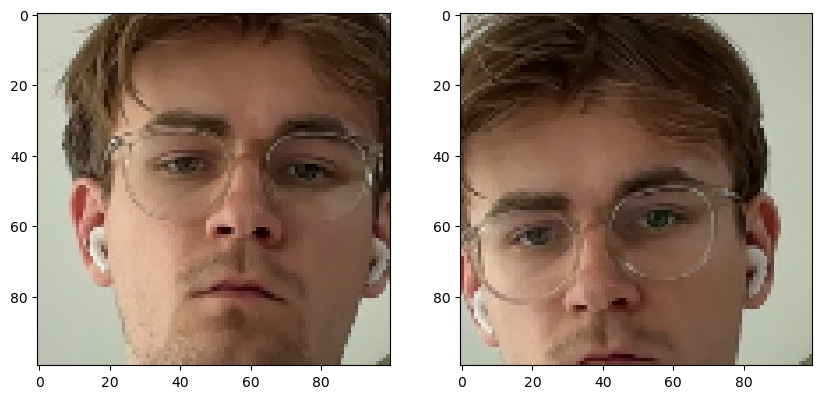

In [33]:
sample = 3

plt.figure(figsize=(10,8))

plt.subplot(1,2,1)
plt.imshow(test_input[sample])

plt.subplot(1,2,2)
plt.imshow(test_val[sample])

plt.show()

# Save model

In [32]:
import datetime, os

# Version the model by training time so a re-run never overwrites a prior model.
os.makedirs('../models', exist_ok=True)
RUN_ID = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
MODEL_PATH = f'../models/siamesemodel_{RUN_ID}.keras'
siamese_model.save(MODEL_PATH)
print('saved model ->', MODEL_PATH)

saved model -> ../models/siamesemodel_20260620_174457.keras


In [34]:
import glob, os

def latest_model(models_dir='../models'):
    """Newest models/siamesemodel_<timestamp>.keras (lexical sort = chronological order)."""
    paths = sorted(glob.glob(os.path.join(models_dir, 'siamesemodel_*.keras')))
    if not paths:
        raise FileNotFoundError(f'No siamesemodel_*.keras in {models_dir}: train first, or run `git lfs pull`.')
    return paths[-1]

MODEL_PATH = latest_model()
print('loading model <-', MODEL_PATH)
model = tf.keras.models.load_model(MODEL_PATH,
                                   custom_objects={'L1Dist': L1Dist, 'BinaryCrossentropy': tf.losses.BinaryCrossentropy})

loading model <- ../models/siamesemodel_20260620_174457.keras


# Inference on webcam

In [35]:
app_data_dir = os.path.join('../application_data')
verification_img_path = os.path.join(app_data_dir, 'verification_images')
input_img_path = os.path.join(app_data_dir, 'input_image', 'input.jpg')

def verify(model, detection_threshold=0.5, verification_threshold=0.5):
    results = []
    for image in os.listdir(verification_img_path):
        input_img = preprocess(input_img_path)
        validation_img = preprocess(os.path.join(verification_img_path, image))

        input_img = tf.expand_dims(input_img, axis=0)
        validation_img = tf.expand_dims(validation_img, axis=0)

        result = model.predict([input_img, validation_img])
        results.append(result)

    # Detection Threshold: Metric above which a prediction is considered positive
    detection = np.sum(np.array(results) > detection_threshold)

    # Verification Threshold: Proportion of positive predictions / total positive samples
    verification = detection / len(os.listdir(verification_img_path))

    verified = verification > verification_threshold

    return results, verified

In [36]:
window_name = 'frame'
cap = cv2.VideoCapture(0)
frame = None

CROP = 400

try:
    if not cap.isOpened():
        raise RuntimeError('Could not open webcam')

    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)

    while True:
        ret, frame = cap.read()
        if not ret or frame is None:
            print('Webcam read failed, stopping capture loop.')
            break

        # center crop
        h, w = frame.shape[:2]
        y0 = max((h - CROP) // 2, 0)
        x0 = max((w - CROP) // 2, 0)
        frame = frame[y0:y0+CROP, x0:x0+CROP, :]

        cv2.imshow(window_name, frame)

        key = cv2.waitKey(1) & 0xFF
        if key == ord('v'):
            cv2.imwrite(input_img_path, frame)
            results, verified = verify(model, 0.9, 0.7)
            print(verified)

        # Exit on q or ESC
        elif key == ord('q') or key == 27:
            break

        if cv2.getWindowProperty(window_name, cv2.WND_PROP_VISIBLE) < 1:
            break
except KeyboardInterrupt:
    print('Capture interrupted by user.')
finally:
    cap.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━